# Enrich layer test
## Test against AGO

In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

from arcgis.gis import GIS
#gis = GIS(profile="your_online_profile")
gis = GIS('https://geosaurus.maps.arcgis.com', 'arcgis_python', 'amazing_arcgis_123', verify_cert=False)

In [2]:
from arcgis.features.enrich_data import enrich_layer

<Item title:"USA Block Groups" type:Feature Layer Collection owner:esri_dm>
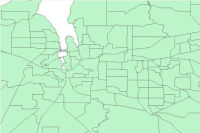

In [3]:
item = gis.content.search('title: "USA Block Groups"', 'Feature layer', outside_org=True)[0]
item

In [4]:
block_groups = item.layers[0]

In [5]:
import arcgis
arcgis.env.verbose = False

In [6]:
block_groups.filter = "STCOFIPS = '48167'"

**Run async**

In [7]:
%%time
import datetime
blkgrp_enrich = enrich_layer(block_groups,
#                              analysis_variables=["AtRisk.MP27002A_B","crime.CRMCYTOTC","crime.CRMCYPERC","crime.CRMCYMURD","crime.CRMCYRAPE","crime.CRMCYROBB","crime.CRMCYASST","crime.CRMCYPROC","crime.CRMCYBURG","crime.CRMCYLARC","crime.CRMCYMVEH","crime.TOTCAGG","crime.PERCAGG","crime.MURDAGG","crime.RAPEAGG","crime.ROBBAGG","crime.ASSTAGG","crime.PROCAGG","crime.BURGAGG","crime.LARCAGG","crime.MVEHAGG","LandscapeFacts.FEDLANDPT","retailmarketplace.RTSALESTOT"],
                             analysis_variables=["AtRisk.MP27002A_B"],
                             country='US',
                             output_name=f'enrich_{datetime.datetime.now().microsecond}',
                             return_boundaries=True, future=True)

Wall time: 2.9 s


In [8]:
assert isinstance(blkgrp_enrich.result(), Item)
blkgrp_enrich.result()

<Item title:"enrich_622267" type:Feature Layer Collection owner:arcgis_python>

In [9]:
blkgrp_enrich.result().delete()

True

In [10]:
point_item = gis.content.get('1f163950afbb4bf39f3ee67cf411761d')

<Item title:"Esri Regional Offices US" type:Feature Layer Collection owner:lsarow_eoe>
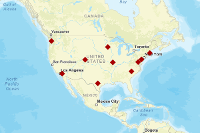

In [11]:
point_item

**Run sync**

In [12]:
%%time
from datetime import datetime
blkgrp_enrich = enrich_layer(point_item.layers[0],
                             analysis_variables=["AtRisk.MP27002A_B"],
                             country='US',
                             buffer_type='Walking Distance',
                             distance=4,
                             units='Meters',
                             output_name='enrich_' + str(datetime.now().microsecond),
                             return_boundaries=True)

Wall time: 21.7 s


In [13]:
assert isinstance(blkgrp_enrich, Item)
blkgrp_enrich

<Item title:"enrich_701253" type:Feature Layer Collection owner:arcgis_python>

In [14]:
blkgrp_enrich.delete()

True

## Run against Portal
#### Test Overwrite

In [15]:
#import sys
#sys.path.insert(0, r"C:\\ipython_workfolder\\geosaurus\\src")
from arcgis.gis import GIS

# portal = GIS(profile="your_portal_profile", verify_cert=False,)
portal = GIS('https://dlltesting.dev.geocloud.com/portal', 'portaladmin', 
             verify_cert=False)

item = portal.content.get("8c3a85d4032049ff8333965c6a2a6219")
layer1 = item.layers[0]
layer2 = item.layers[3]

<Item title:"Esri Regional Offices US" type:Feature Layer Collection owner:lsarow_eoe>
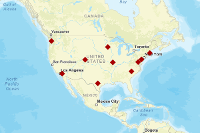

In [16]:
point_item

In [17]:
%%time
test = test = enrich_layer(point_item.layers[0],
                    analysis_variables=["AtRisk.MP27002A_B"],
                    country='US',
                    output_name='enrich_overwrite',
                    return_boundaries=True, )

CPU times: user 295 ms, sys: 32.8 ms, total: 328 ms
Wall time: 21.1 s


In [18]:
fl_to_overwrite = portal.content.get(test.id).layers[0]
print(fl_to_overwrite)
print(test.id)

<FeatureLayer url:"https://dlltesting.dev.geocloud.com/server/rest/services/Hosted/enrich_overwrite/FeatureServer/0">
a30539949f884efba52515d62d24de80


In [19]:
fl_to_overwrite.query(return_count_only=True)

10

In [20]:
fl_to_overwrite.query(as_df=True)

,country,city,address_1,address_2,address_3,accuracy,createdate,contact_us,bufferunitsalias,officetype,...,officename,bufferunits,phone,cntrycode,mp27002a_b,areatype,tagline,editdate,objectid,SHAPE
0,United States,Middleton,35 Village Rd,Suite 501,,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Boston,esriMiles,978-777-4543,US,3108,RingBuffer,Serving the Northeastern United States,2019-12-19 00:29:07,1,"{""rings"": [[[-7900594.572400002, 5253211.07285..."
1,United States,Louisville,167 S. Taylor Ave,None,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Denver,esriMiles,303-449-7779,US,2156,RingBuffer,Serving the Western United States,2020-03-07 01:15:53,2,"{""rings"": [[[-11702050.7255, 4863704.825235605..."
2,United States,St. Paul,880 Blue Gentian Rd,Suite 200,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Minneapolis,esriMiles,651-454-0600,US,1302,RingBuffer,Serving the Upper Midwestern United States,2019-12-19 00:29:07,3,"{""rings"": [[[-10367395.930099996, 5601302.0659..."
3,United States,Olympia,111 Market St. N.E.,Suite 250,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Olympia,esriMiles,360-754-4727,US,6707,RingBuffer,Serving the Northwestern United States,2019-12-19 00:29:07,4,"{""rings"": [[[-13681343.603000002, 5952628.1563..."
4,United States,Redlands,380 New York St,None,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri California,esriMiles,909-793-2853,US,9648,RingBuffer,Serving the Southwestern United States and Pac...,2019-12-19 00:29:07,5,"{""rings"": [[[-13045885.362300003, 4038535.2315..."
5,United States,San Antonio,19026 Ridgewood Parkway,Suite 309,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri San Antonio,esriMiles,210-499-1044,US,5238,RingBuffer,Serving the Southcentral U.S. and Cayman Islands,2019-12-19 00:29:07,6,"{""rings"": [[[-10960271.879699996, 3456383.8786..."
6,United States,St. Charles,3060 Little Hills Expressway,None,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri St. Louis,esriMiles,636-949-6620,US,6173,RingBuffer,Serving the Midwestern United States,2019-12-19 00:29:07,7,"{""rings"": [[[-10073194.144300003, 4697137.1156..."
7,United States,Vienna,8615 Westwood Center Dr,None,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,"Esri Washington, DC",esriMiles,703-506-9515,US,10913,RingBuffer,Serving the Federal Government,2019-12-20 18:52:26,8,"{""rings"": [[[-8599154.409200002, 4713456.84842..."
8,United States,Chesterbrook,1325 Morris Drive,Suite 201,Chesterbrook Corporate Center,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Philadelphia,esriMiles,610-644-3374,US,3402,RingBuffer,Serving the Central Eastern United States,2019-12-19 00:29:07,9,"{""rings"": [[[-8400982.4137, 4878255.758876279]..."
9,United States,Charlotte,6210 Ardrey Kell Road,Suite 200,None,Building,2018-08-02 22:38:13,Yes,Miles,US Regional Office,...,Esri Charlotte Waverly,esriMiles,704-541-9810,US,6110,RingBuffer,Serving the Southeastern United States,2019-12-19 00:29:07,10,"{""rings"": [[[-8990809.733000001, 4172834.02799..."


In [21]:
%%time
overwrite = enrich_layer(point_item.layers[0],
                    analysis_variables=["AtRisk.MP27002A_B"],
                    country='US',
                    output_name=fl_to_overwrite,
                    return_boundaries=True, 
                    context={"overwrite":True})

CPU times: user 93.8 ms, sys: 9.7 ms, total: 104 ms
Wall time: 15.3 s


In [22]:
# Notice the ids are the same, if overwrite fails then fl is appended instead
print(overwrite.layers)
print(overwrite.id)

[<FeatureLayer url:"https://dlltesting.dev.geocloud.com/server/rest/services/Hosted/enrich_overwrite/FeatureServer/0">]
a30539949f884efba52515d62d24de80


In [23]:
overwrite.layers[0].query(as_df=True)

,country,city,address_1,address_2,address_3,accuracy,createdate,contact_us,bufferunitsalias,officetype,...,officename,bufferunits,phone,cntrycode,mp27002a_b,areatype,tagline,editdate,objectid,SHAPE
0,United States,Middleton,35 Village Rd,Suite 501,,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Boston,esriMiles,978-777-4543,US,3108,RingBuffer,Serving the Northeastern United States,2019-12-19 00:29:07,1,"{""rings"": [[[-7900594.572400002, 5253211.07285..."
1,United States,Louisville,167 S. Taylor Ave,None,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Denver,esriMiles,303-449-7779,US,2156,RingBuffer,Serving the Western United States,2020-03-07 01:15:53,2,"{""rings"": [[[-11702050.7255, 4863704.825235605..."
2,United States,St. Paul,880 Blue Gentian Rd,Suite 200,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Minneapolis,esriMiles,651-454-0600,US,1302,RingBuffer,Serving the Upper Midwestern United States,2019-12-19 00:29:07,3,"{""rings"": [[[-10367395.930099996, 5601302.0659..."
3,United States,Olympia,111 Market St. N.E.,Suite 250,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Olympia,esriMiles,360-754-4727,US,6707,RingBuffer,Serving the Northwestern United States,2019-12-19 00:29:07,4,"{""rings"": [[[-13681343.603000002, 5952628.1563..."
4,United States,Redlands,380 New York St,None,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri California,esriMiles,909-793-2853,US,9648,RingBuffer,Serving the Southwestern United States and Pac...,2019-12-19 00:29:07,5,"{""rings"": [[[-13045885.362300003, 4038535.2315..."
5,United States,San Antonio,19026 Ridgewood Parkway,Suite 309,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri San Antonio,esriMiles,210-499-1044,US,5238,RingBuffer,Serving the Southcentral U.S. and Cayman Islands,2019-12-19 00:29:07,6,"{""rings"": [[[-10960271.879699996, 3456383.8786..."
6,United States,St. Charles,3060 Little Hills Expressway,None,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri St. Louis,esriMiles,636-949-6620,US,6173,RingBuffer,Serving the Midwestern United States,2019-12-19 00:29:07,7,"{""rings"": [[[-10073194.144300003, 4697137.1156..."
7,United States,Vienna,8615 Westwood Center Dr,None,None,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,"Esri Washington, DC",esriMiles,703-506-9515,US,10913,RingBuffer,Serving the Federal Government,2019-12-20 18:52:26,8,"{""rings"": [[[-8599154.409200002, 4713456.84842..."
8,United States,Chesterbrook,1325 Morris Drive,Suite 201,Chesterbrook Corporate Center,Building,2012-06-14 21:16:23,Yes,Miles,US Regional Office,...,Esri Philadelphia,esriMiles,610-644-3374,US,3402,RingBuffer,Serving the Central Eastern United States,2019-12-19 00:29:07,9,"{""rings"": [[[-8400982.4137, 4878255.758876279]..."
9,United States,Charlotte,6210 Ardrey Kell Road,Suite 200,None,Building,2018-08-02 22:38:13,Yes,Miles,US Regional Office,...,Esri Charlotte Waverly,esriMiles,704-541-9810,US,6110,RingBuffer,Serving the Southeastern United States,2019-12-19 00:29:07,10,"{""rings"": [[[-8990809.733000001, 4172834.02799..."


In [24]:
overwrite.delete()

True